# Calculating Magnetic Data

This code uses SimPEG functions to calculate the magnetic data of an array of Minecraft blocks.

## Importing the data

In [24]:
import numpy as np
from numpy import random
import pandas as pd
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm


#from gdpc import __url__, Editor, Block

#editor = Editor(buffering=True)

sub_grid_init = np.loadtxt("subsurface_2.csv",delimiter=" ", dtype=object)

sub_grid = sub_grid_init.reshape((200, 200, 44))
#sub_grid = np.flip(sub_grid,axis=2)

## Importing SimPEG functions

In [3]:
# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps, utils

# discretize functionality
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

mpl.rcParams.update({"font.size": 14})

save_output = False  # Optional

## Setting up Topography

In [6]:
#set up topography
[x_topo, y_topo] = np.meshgrid(np.linspace(0, 200, 51), np.linspace(0, 200, 51))
z_topo = np.zeros_like(x_topo)

In [8]:
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[x_topo, y_topo, z_topo]

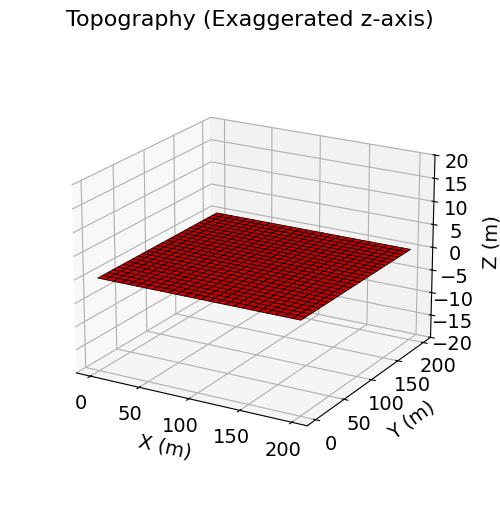

In [7]:
# plot topography
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([z_topo.max() - 20, z_topo.max() + 20])
ax.plot_surface(x_topo, y_topo, z_topo, color="r", edgecolor="k", linewidth=0.5)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=20.0)

## Setting up observation grid, survey, and background magnetic field

In [9]:
# Define the observation locations as an (N, 3) numpy array or load them.
x = np.linspace(0.5, 199.5, 200)
y = np.linspace(0.5, 199.5, 200)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y]) + 10  # Flight height 10 m above surface.
receiver_locations = np.c_[x, y, z]

In [10]:
# Define the component(s) of the field we want to simulate as a list of strings.
# Here we simulate total magnetic intensity data.
components = ["tmi"]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]

# Define the inducing field
inclination = 90  # inclination [deg]
declination = 0  # declination [deg]
amplitude = 50000  # amplitude [nT]

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

## Setting up mesh of subsurface

In [11]:
# Generate tensor mesh with top at z = 0 m
dh = 1.0
hx = [(dh, 200)]
hy = [(dh, 200)]
hz = [(dh, 44)]
mesh = TensorMesh([hx, hy, hz], "CCN")

# Shift vertically to top same as maximum topography
mesh.origin += np.r_[100.0, 100.0, z_topo.max()]

In [12]:
mesh

TensorMesh: 1,760,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    200          0.00        200.00      1.00      1.00    1.00
   y    200          0.00        200.00      1.00      1.00    1.00
   z     44        -44.00          0.00      1.00      1.00    1.00

In [13]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_xyz)

In [14]:
# Define mapping from model to active cells. The model consists of a
# susceptibility value for each cell below the Earth's surface.
n_active = int(active_cells.sum())
model_map = maps.IdentityMap(nP=n_active)

## Setting up magnetic susceptibility grid

In [15]:
#set up mag sus grid
mag_grid = np.ones(shape = (200, 200, 44))
mag_grid = 0.0001 * mag_grid
for x in range(0,200):
    for z in range(0,200):
        for y in range(0,44):
            if sub_grid[x,z,y] == "minecraft:iron_ore":
                mag_grid[x,z,y] = 0.02
            if sub_grid[x,z,y] == "minecraft:gold_ore":
                mag_grid[x,z,y] = 0.015
            if sub_grid[x,z,y] == "minecraft:diamond_ore":
                mag_grid[x,z,y] = 0.01

In [16]:
model = utils.mkvc(mag_grid)

In [17]:
# Mapping to ignore inactive cells when plotting model
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

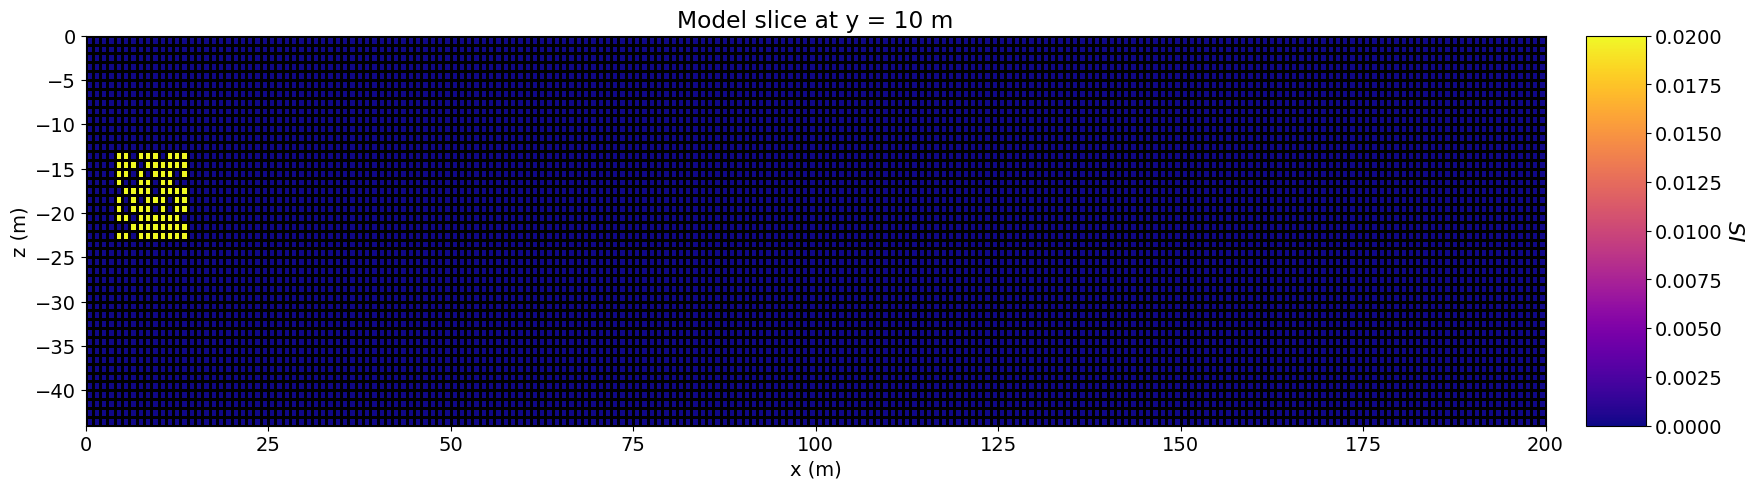

In [103]:
# Plot Susceptibility Model
fig = plt.figure(figsize=(20, 5))
ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])

norm = mpl.colors.Normalize(vmin=0, vmax=np.max(model))
mesh.plot_slice(
    plotting_map * model,
    normal="Y",
    ax=ax1,
    ind=10,
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 10 m")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.78])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()

## Calculating the magnetic data

In [18]:
simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    model_type="scalar",
    chiMap=model_map,
    active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

In [19]:
dpred = simulation.dpred(model)

In [20]:
dpred_2d = dpred.reshape(200,200)
dpred_2d.shape

(200, 200)

## Plotting the data

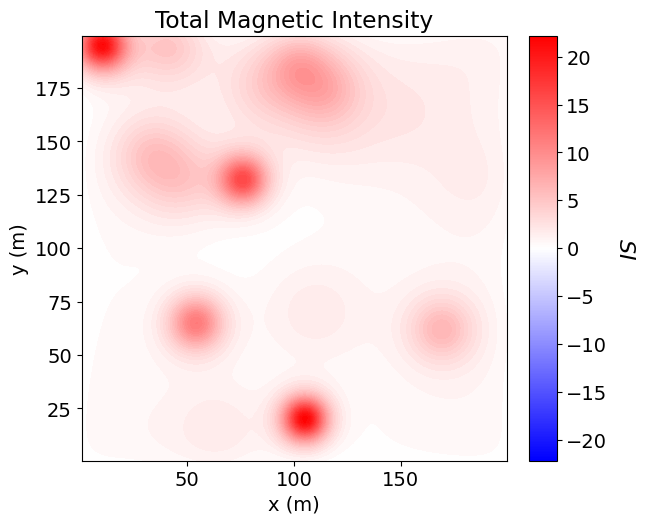

In [21]:
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85])

norm = mpl.colors.Normalize(vmin=-np.max(np.abs(dpred_2d)), vmax=np.max(np.abs(dpred_2d)))
plot2Ddata(
    receiver_list[0].locations,
    dpred,
    ax=ax1,
    ncontour=40,
    contourOpts={"cmap": mpl.cm.bwr, "norm": norm},
)
ax1.set_title("Total Magnetic Intensity")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.81, 0.1, 0.04, 0.85])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr
)
cbar.set_label("$SI$", rotation=270, labelpad=20, size=16)

plt.show()

In [18]:
mag_grid = np.loadtxt('mag_data_2.txt', delimiter=' ',dtype=float)
x_p = np.arange(0,200)
y_p = np.arange(0,200)

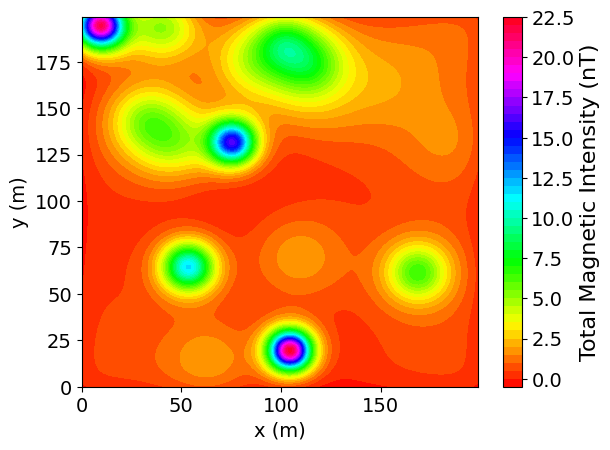

In [23]:
plt.contourf(x_p,y_p,mag_grid,50,origin='lower', cmap='hsv')
#plt.title("Total Magnetic Intensity")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
cbar = plt.colorbar()
cbar.set_label('Total Magnetic Intensity (nT)', size=16)
plt.savefig('Magnetic_data_2.png', bbox_inches='tight')

In [ ]:
# save data if you might need it later
np.savetxt('mag_data_2.txt',dpred_2d, delimiter=' ')

In [ ]:
# check max and min of data for making colourmap for putting map into minecraft later
np.min(dpred_2d)

np.float64(-0.25809759431154505)

In [ ]:
if save_output:
    dir_path = os.path.sep.join([".", "fwd_magnetics_induced_3d_outputs"]) + os.path.sep
    if not os.path.exists(dir_path):
        os.mkdir(dir_path)

    fname = dir_path + "magnetics_topo.txt"
    np.savetxt(fname, np.c_[topo_xyz], fmt="%.4e")

    rng = np.random.default_rng(seed=211)
    maximum_anomaly = np.max(np.abs(dpred))
    noise = rng.normal(scale=0.02 * maximum_anomaly, size=len(dpred))
    fname = dir_path + "magnetics_data.obs"
    np.savetxt(fname, np.c_[receiver_locations, dpred + noise], fmt="%.4e")